<a href="https://colab.research.google.com/github/bentemarij/DSRP-Small-Body-Close-Approaches-BMdZ/blob/main/BMdZ_DSRP_Colab_Small_Body_Close_Approaches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/SB%20Close%20Approaches/earth_close_approaches_50yr.csv')
df.info()
print(df.describe())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186255 entries, 0 to 186254
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   des       186255 non-null  object 
 1   cd        186255 non-null  object 
 2   dist      186255 non-null  float64
 3   dist_min  186255 non-null  float64
 4   dist_max  186255 non-null  float64
 5   v_rel     186255 non-null  float64
 6   h         186065 non-null  float64
 7   diameter  5375 non-null    float64
dtypes: float64(6), object(2)
memory usage: 11.4+ MB
                dist       dist_min       dist_max          v_rel  \
count  186255.000000  186255.000000  186255.000000  186255.000000   
mean        0.237560       0.223031       0.256043      12.905789   
std         0.147360       0.144774       0.156881       6.684920   
min         0.000014       0.000000       0.000025       0.056485   
25%         0.109646       0.095617       0.122456       7.764031   
50%         0.228977   

,des,cd,dist,dist_min,dist_max,v_rel,h,diameter
0,2015 RT1,1976-Jan-01 04:35,0.111611,0.109327,0.113897,11.086209,25.410,NaN
1,2025 JH2,1976-Jan-01 06:22,0.171429,0.171313,0.171548,5.842427,27.050,NaN
2,2001 KU66,1976-Jan-01 14:29,0.440401,0.426042,0.466510,10.401878,24.100,NaN
3,2015 TG24,1976-Jan-01 15:04,0.451030,0.425241,0.477393,12.519296,26.680,NaN
4,2002 TX59,1976-Jan-02 01:26,0.459706,0.459668,0.459744,6.299898,23.900,NaN
...,...,...,...,...,...,...,...,...
186250,2026 LD1,2026-Jun-12 19:50,0.130207,0.128030,0.132384,10.184379,23.314,NaN
186251,2026 LK1,2026-Jun-12 21:43,0.005988,0.005983,0.005993,5.837560,27.872,NaN
186252,388945,2026-Jun-12 22:12,0.112264,0.112264,0.112264,7.484532,20.440,NaN
186253,2018 NC15,2026-Jun-12 22:50,0.131353,0.131353,0.131354,10.225792,21.810,NaN


# Initial Cleaning and Exploration

**Possible Issues**

May be some issues with the 'des' column, there are 2 formats for the name of the small body object. Can be either their provisional or permanent name.
* Ex: line 0 - 2015 RT1 (provisional), line 15 - 523808 (permanent)
* Source: https://sci.esa.int/web/home/-/30244-asteroid-numbers-and-names

May be some issues with the 'diameter' column, as many of the values are NaN.
* 5375 non-null out of 186255 lines (dtype: float64)

In [16]:
df['des'].value_counts()

,count
des,
469219,101
2025 PN7,83
2017 FZ2,81
2023 FW13,81
2021 EY1,78
...,...
2026 LD1,1
2026 LT,1
2026 KT2,1


Each of the rows does not represent a small body, it respresents a close approach. The most approaches made by a single body is 101 by 469219. After quick searches it seems like the majority of the top of this list are Earth's qausi moons.

In [17]:
df469219 = df[df['des'] == '469219']
df469219.tail(15)

,des,cd,dist,dist_min,dist_max,v_rel,h,diameter
139565,469219,2019-Apr-19 16:17,0.150700,0.150699,0.150701,4.117841,24.31,NaN
142279,469219,2019-Oct-08 04:43,0.151210,0.151210,0.151211,4.331279,24.31,NaN
145682,469219,2020-Apr-13 21:23,0.155974,0.155973,0.155975,4.046718,24.31,NaN
148897,469219,2020-Oct-12 08:33,0.146759,0.146758,0.146760,4.423755,24.31,NaN
152309,469219,2021-Apr-08 12:39,0.160722,0.160721,0.160723,3.950523,24.31,NaN
155836,469219,2021-Oct-17 11:30,0.141673,0.141672,0.141674,4.508019,24.31,NaN
159120,469219,2022-Apr-02 18:16,0.164750,0.164749,0.164751,3.821477,24.31,NaN
162786,469219,2022-Oct-22 04:42,0.136348,0.136348,0.136349,4.549048,24.31,NaN
165776,469219,2023-Mar-27 18:56,0.167866,0.167865,0.167867,3.658830,24.31,NaN
169772,469219,2023-Oct-26 13:35,0.130763,0.130762,0.130763,4.592505,24.31,NaN


**Accurate Columns**

After comparing the df469219 with information about 469219 and also finding the official NASA data base, I can now accurately determine each of the columns:
* `des` - primary designation of the asteroid or comet (e.g., 443, 2000 SG344)
* `cd` - time of close-approach (formatted calendar date/time, TDB)
* `dist` - nominal approach distance (au)
* `dist_min` - minimum (3-sigma) approach distance (au)
* `dist_max` - maximum (3-sigma) approach distance (au)
* `v_rel` - velocity relative to the approach body at close approach (km/s)
* `h` - absolute magnitude H (mag)
* `diameter` - diameter of the body (km)
  * `NaN` if not known

---

**Sources/links used:**

* https://www.spacereference.org/asteroid/469219-kamooalewa-2016-ho3
* https://ssd-api.jpl.nasa.gov/doc/cad.html

---

**Possible Research Question**

How do the distances of close approaches vary across decades, and what does this show about changes in detection methods?

* From the data set doc, this sounds interesting, but I would need to start looking into changes in the technology used in each decade.

In [18]:
# First, I want to go through and add a column called year
# This column will contain the year of every close approach
# It will be more useful to me than the exact date and time of each aproach

dateList = df['cd']
yearList = []
index = 0
for date in dateList:
  yearList.append(int((df['cd'][index])[0:4]))
  index = index + 1
df.insert(2, 'year', yearList, True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186255 entries, 0 to 186254
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   des       186255 non-null  object 
 1   cd        186255 non-null  object 
 2   year      186255 non-null  int64  
 3   dist      186255 non-null  float64
 4   dist_min  186255 non-null  float64
 5   dist_max  186255 non-null  float64
 6   v_rel     186255 non-null  float64
 7   h         186065 non-null  float64
 8   diameter  5375 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 12.8+ MB


Sources used for adding the year column:
* https://www.geeksforgeeks.org/pandas/adding-new-column-to-existing-dataframe-in-pandas/
* https://www.w3schools.com/python/python_lists_add.asp

In [19]:
# I also want to go through and make the dates a bit more intuitive, using the ISO format
# I would also like to add a new decades column, so I can sort the data into larger chunks
isoList = []
decadeList = []
index = 0
monthDic = { 'Jan' : '01', 'Feb' : '02', 'Mar' : '03', 'Apr' : '04', 'May' : '05', 'Jun' : '06', 'Jul' : '07', 'Aug' : '08', 'Sep' : '09', 'Oct' : '10', 'Nov' : '11', 'Dec' : '12' }
for date in dateList:
  iso = (df['cd'][index])[0:4] + '-' + monthDic[(df['cd'][index])[5:8]] + '-' + (df['cd'][index])[9:11] + 'T' + (df['cd'][index])[13:18] + '[TBD]'
  isoList.append(iso)
  decadeList.append((df['cd'][index])[0:3] + '0s')
  index = index + 1
df['cd'] = isoList
df.insert(3, 'decade', decadeList, True)
df.head()

,des,cd,year,decade,dist,dist_min,dist_max,v_rel,h,diameter
0,2015 RT1,1976-01-01T4:35[TBD],1976,1970s,0.111611,0.109327,0.113897,11.086209,25.41,NaN
1,2025 JH2,1976-01-01T6:22[TBD],1976,1970s,0.171429,0.171313,0.171548,5.842427,27.05,NaN
2,2001 KU66,1976-01-01T4:29[TBD],1976,1970s,0.440401,0.426042,0.466510,10.401878,24.10,NaN
3,2015 TG24,1976-01-01T5:04[TBD],1976,1970s,0.451030,0.425241,0.477393,12.519296,26.68,NaN
4,2002 TX59,1976-01-02T1:26[TBD],1976,1970s,0.459706,0.459668,0.459744,6.299898,23.90,NaN


# Inital Visualizations and Observations

**Visualization 1**

I want to start by looking at if there is any clear correlation between decade and distance, to see if the first research question is a valid option.

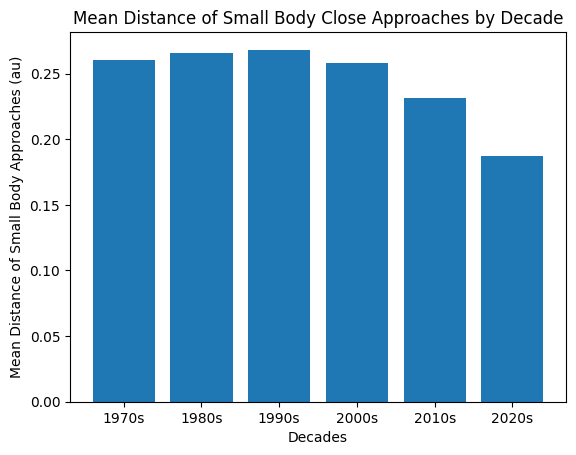

In [20]:
dec = df['decade'].unique()
decDist = []
index = 0
for group in dec:
  decDist.append(((df[df['decade'] == group])['dist']).mean())

plt.bar(dec, decDist)
plt.title('Mean Distance of Small Body Close Approaches by Decade')
plt.xlabel('Decades')
plt.ylabel('Mean Distance of Small Body Approaches (au)')

plt.show()

**Observations**

It seems as though the mean distance is smaller, which is ineteresting as it is different than I expected.

Based on this visualization and the assumtion that the characteristics of small body objects close approaches does not change drastically through the decades, I am guessing the following is true:

1)   We are able to detect more close approaches each decade
2)   Of those close approaches more of them have been closer -- so we have either gotten better at detecting objects that are closer to earth, or we have gotten better at detecting a certain kind of small body which is more likely to come closer to the earth

Lastly, I would also like to look at the error margins for each decade, by subtracting the min and the max distance because it is also possible we used to have higher error margins and falsely assumed that the objects were further away then they were.

---

**Visualization 2a**

I want to check if it is true that we have been able to detect an increased number of small bodies making close approaches as we move through the decades. To do this, I will create a bar chart of the number of approaches in the dataframe for each decade.

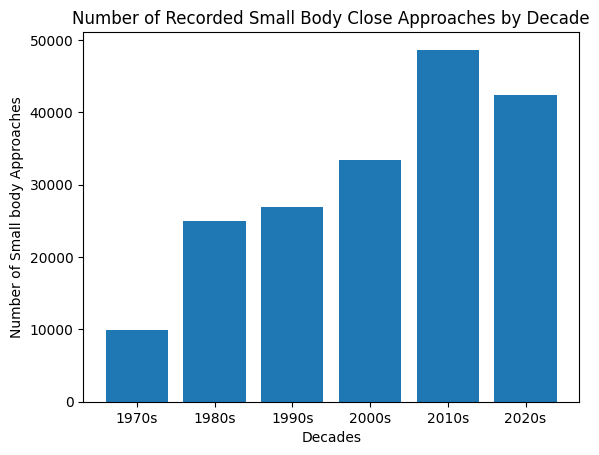

In [21]:
decNum = []
index = 0
for group in dec:
  decNum.append(len(df[df['decade'] == group]))

plt.bar(dec, decNum)
plt.title('Number of Recorded Small Body Close Approaches by Decade')
plt.xlabel('Decades')
plt.ylabel('Number of Small body Approaches')

plt.show()

Based on this chart, we can see that the number of close approaches is indeed going up each decade. The likely reason why the 2020s is lower than 2010s is that we are only about 60% done with the 2020s. To account for this, I will also create a graph for each individual year to double check, which will double check the previous statement.

**Visualization 2b**

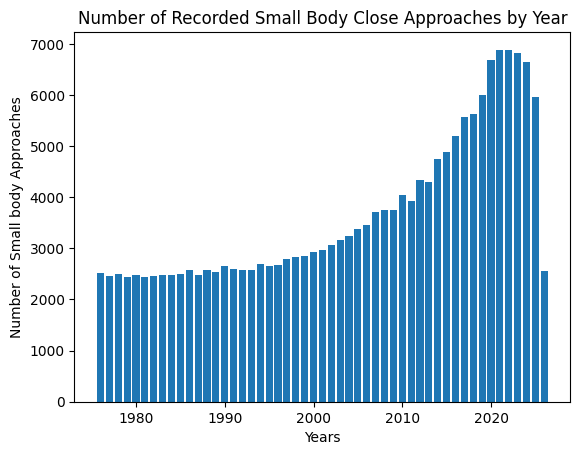

In [22]:
yrs = df['year'].unique()
yearNum = []
index = 0
for group in yrs:
  yearNum.append(len(df[df['year'] == group]))

plt.bar(yrs, yearNum)
plt.title('Number of Recorded Small Body Close Approaches by Year')
plt.xlabel('Years')
plt.ylabel('Number of Small body Approaches')

plt.show()

This graph comfirms that the upwards trend has indeed continued into the 2020s.

---

**Visualization 3a**

Now, I want to check what the margin or error looks like in each year. I am going to make a line plot with 3 lines representing the dist_min, dist, and dist_max.

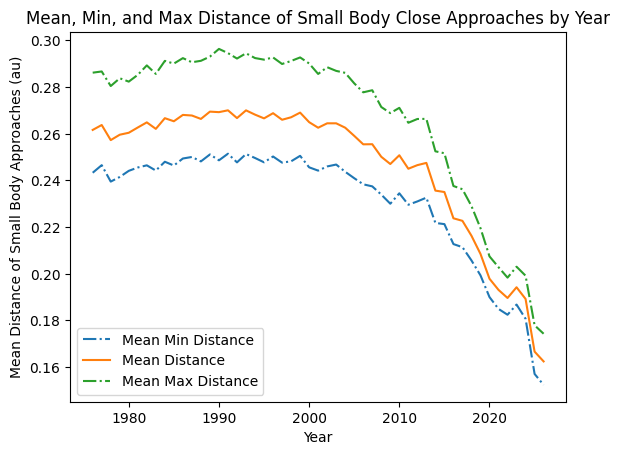

In [23]:
yearDistMin = []
yearDist = []
yearDistMax = []
index = 0
for group in yrs:
  yearDistMin.append(((df[df['year'] == group])['dist_min']).mean())
  yearDist.append(((df[df['year'] == group])['dist']).mean())
  yearDistMax.append(((df[df['year'] == group])['dist_max']).mean())

plt.plot(yrs, yearDistMin, label = 'Mean Min Distance', linestyle = '-.')
plt.plot(yrs, yearDist, label = 'Mean Distance')
plt.plot(yrs, yearDistMax, label = 'Mean Max Distance', linestyle = '-.')
plt.legend()
plt.title('Mean, Min, and Max Distance of Small Body Close Approaches by Year')
plt.xlabel('Year')
plt.ylabel('Mean Distance of Small Body Approaches (au)')
plt.show()

Sources used to create add multiple lines to one plot:
* https://www.geeksforgeeks.org/python/plot-multiple-lines-in-matplotlib/

Based on this plot, it seems like the error margins are getting closer through the years. However, you can still clearly see the mean distance going down.

**Visualization 3b**

To double check this result, I am going to produce a bar chart of the uncertainty (defined as dist_max - dist_min), to double check that it is going down.

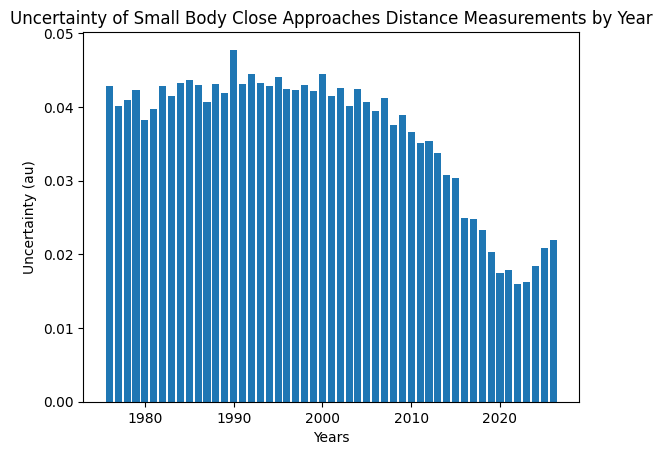

In [24]:
yearUncer = []
index = 0
while (index < len(yrs)):
  yearUncer.append(yearDistMax[index] - yearDistMin[index])
  index = index + 1

plt.bar(yrs, yearUncer)
plt.title('Uncertainty of Small Body Close Approaches Distance Measurements by Year')
plt.xlabel('Years')
plt.ylabel('Uncertainty (au)')
plt.show()

---
**Visualization 4**

I just want to check whether or not the velocity has changed, because if it has we may be able to determine that we have gotten better at detecting faster or slower objects, one of which may be more likely to have a close approach with Earth. However, this plot is mostly unimportant, since it would be difficult to think of a question to go along with it.

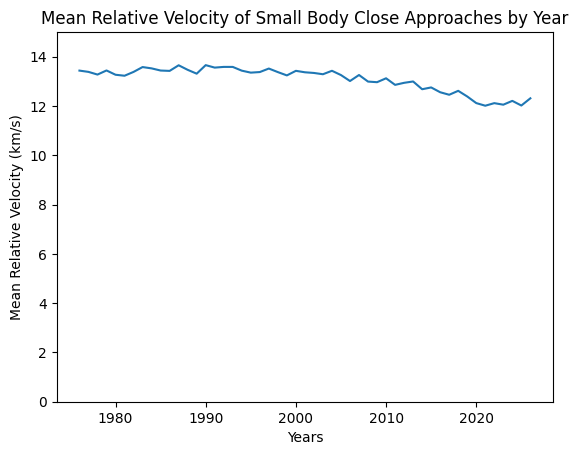

In [28]:
yearVel = []
index = 0
for group in yrs:
  yearVel.append((df[df['year'] == group])['v_rel'].mean())

plt.plot(yrs, yearVel)
plt.ylim(0, 15)
plt.title('Mean Relative Velocity of Small Body Close Approaches by Year')
plt.xlabel('Years')
plt.ylabel('Mean Relative Velocity (km/s)')
plt.show()

---
**Visualization 5**
Similar to number 4, but this time I want to look a bit at h, the absolute magnitude.

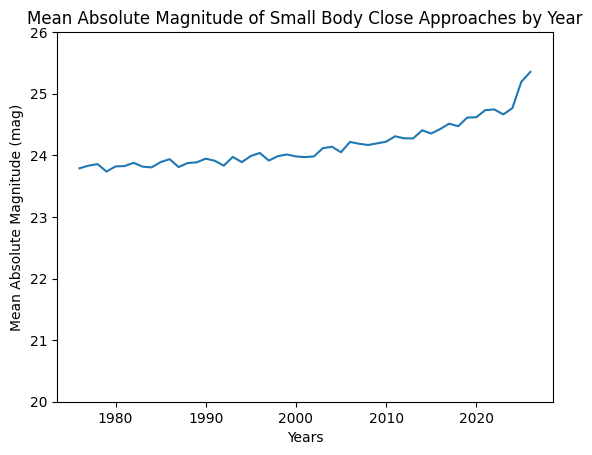

In [31]:
yearH = []
index = 0
for group in yrs:
  yearH.append((df[df['year'] == group])['h'].mean())

plt.plot(yrs, yearH)
plt.ylim(20, 26)
plt.title('Mean Absolute Magnitude of Small Body Close Approaches by Year')
plt.xlabel('Years')
plt.ylabel('Mean Absolute Magnitude (mag)')
plt.show()

# History of Small Body Detection

Since we have noticed that there are many changes over time, it makes sense to look into how detection equipment has changed.

---

**History of Asteroid Discovery**

`1970s:`

Palomar Planet-Crossing Asteroid Survey (PCAS):
* Images were taken of the night sky using photographic plates, which were quickly switched back and forth using a blink comparator. They used this to detect changes in the sky, so that they could spot moving near Earth objects.

`1980s:`

Palomar Asteroid and Comet Survey (PACS):
* Used a stereoscopic microscope and hypersensitized Kodak Tech-Pan 4415 photographic film. Similar to the previous survey

---
**Question Brainstorming:**

What I want to include:
I want to discuss changes in asteroid detection over time, for example looking at which types of asteroids we have become more effective at detecting.

**TO BE CONTINUED: COME BACK AND FINISH!!!**